# Análise Refinada PNAD COVID-19

**Objetivo:** Responder 3 perguntas temáticas usando no máximo 20 variáveis selecionadas da PNAD COVID-19 (IBGE — **Setembro, Outubro e Novembro/2020**), gerando insumos para recomendações hospitalares em caso de novo surto.

| Tema | Perguntas respondidas |
|---|---|
| 1. Sintomas Clínicos | Prevalência, severidade, testagem, comorbidades, perfil demográfico |
| 2. Comportamento da População | Proteção, busca por atendimento, mercado de trabalho, isolamento |
| 3. Características Econômicas | Renda, auxílios, proteção social, vulnerabilidade |

**Cobertura temporal:** Os três meses cobrem o período de **desaceleração da primeira onda** da COVID-19 no Brasil, permitindo observar a evolução mês a mês dos indicadores.

**Nota metodológica:** Todas as agregações usam `peso_amostral` para representar a população brasileira corretamente.

In [1]:
import os
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

os.chdir('/Users/marcusferreira/Documents/FIAP/Data Analytics/Fase 3/Tech Challenge')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

spark = (SparkSession.builder
    .appName('refined_analysis_pnad')
    .config('spark.ui.enabled', 'false')
    .config('spark.driver.memory', '4g')
    .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')

BASE_PATH = 'output/pnad_covid'
SPECS_PATH = 'output/specs'
os.makedirs(SPECS_PATH, exist_ok=True)

CHAVE_JOIN = ['uf', 'id_domicilio', 'id_morador', 'mes_entrevista']
MESES = ['2020-09', '2020-10', '2020-11']
MES_LABEL = {'2020-09': 'Set/2020', '2020-10': 'Out/2020', '2020-11': 'Nov/2020'}
PERIODO_TXT = 'Set–Nov/2020'
print('Setup OK | CWD:', os.getcwd())

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/12 23:39:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setup OK | CWD: /Users/marcusferreira/Documents/FIAP/Data Analytics/Fase 3/Tech Challenge


In [ ]:
# Lê todas as partições MES_REF (set/out/nov 2020) — a coluna MES_REF é incluída automaticamente.
base_saude = spark.read.parquet(f'{BASE_PATH}/base_saude')
base_comp  = spark.read.parquet(f'{BASE_PATH}/base_comportamento')
base_eco   = spark.read.parquet(f'{BASE_PATH}/base_economico')
dim_perfil = spark.read.parquet(f'{BASE_PATH}/dim_perfil')
dim_loc    = spark.read.parquet(f'{BASE_PATH}/dim_localizacao')

for nome, df in [('base_saude', base_saude), ('base_comportamento', base_comp), 
                  ('base_economico', base_eco), ('dim_perfil', dim_perfil),
                  ('dim_localizacao', dim_loc)]:
    n = df.count()
    meses = sorted([r['MES_REF'] for r in df.select('MES_REF').distinct().collect()])
    print(f'{nome:<22} {n:>10,} linhas | {len(df.columns):>3} colunas | meses: {meses}')

base_saude              1,149,197 linhas |  54 colunas | meses: ['2020-09', '2020-10', '2020-11']
base_comportamento      1,149,197 linhas |  32 colunas | meses: ['2020-09', '2020-10', '2020-11']


base_economico          1,149,197 linhas |  30 colunas | meses: ['2020-09', '2020-10', '2020-11']
dim_perfil              1,149,197 linhas |  23 colunas | meses: ['2020-09', '2020-10', '2020-11']


dim_localizacao         1,149,197 linhas |   9 colunas | meses: ['2020-09', '2020-10', '2020-11']


In [3]:
def pct_pond(df, col, valor='Sim'):
    """Percentual ponderado de registros onde col == valor."""
    total = df.agg(F.sum('peso_amostral')).collect()[0][0]
    sim   = df.filter(F.col(col) == valor).agg(F.sum('peso_amostral')).collect()[0][0] or 0
    return (sim / total * 100) if total else 0

def dist_pond(df, col, ascending=False):
    """Distribuição ponderada de uma coluna categórica."""
    agg = (df.groupBy(col)
             .agg(F.sum('peso_amostral').alias('pop_ponderada'))
             .toPandas()
             .dropna(subset=[col]))
    agg['pct'] = agg['pop_ponderada'] / agg['pop_ponderada'].sum() * 100
    return agg.sort_values('pct', ascending=ascending)

def fmt_pct(ax, axis='y'):
    fmt = mticker.FormatStrFormatter('%.1f%%')
    if axis == 'y':
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

CORES = sns.color_palette('muted')
print('Helpers definidos.')


Helpers definidos.


## 1. Organização do Banco de Dados

### Star Schema

```
                    ┌──────────────┐
                    │  DIM_TEMPO   │
                    │  4 colunas   │
                    └──────┬───────┘
                           │
┌──────────────┐    ┌──────┴───────┐    ┌────────────────────┐
│ DIM_PERFIL   │    │  CHAVE JOIN  │    │  DIM_LOCALIZACAO   │
│ 23 colunas   ├────┤uf+domicilio  ├────┤    9 colunas       │
└──────────────┘    │+morador+mes  │    └────────────────────┘
                    └──────┬───────┘
              ┌────────────┼────────────┐
              ▼            ▼            ▼
        ┌───────────┐ ┌──────────┐ ┌──────────────┐
        │BASE_SAUDE │ │BASE_COMP │ │BASE_ECONOMICO│
        │ 53 colunas│ │29 colunas│ │  29 colunas  │
        └───────────┘ └──────────┘ └──────────────┘
```

**Regra:** `peso_amostral` é obrigatório em todas as agregações para representar corretamente a população brasileira.

**Partição:** cada tabela é particionada por `MES_REF` (formato `AAAA-MM`). Esta análise consolida os 3 meses (set/out/nov 2020), totalizando ~1.149.197 entrevistados.

In [4]:
# Resumo do Star Schema (3 meses)
dim_tempo_full = spark.read.parquet(f'{BASE_PATH}/dim_tempo')

tabelas_info = [
    ('DIM_TEMPO',          dim_tempo_full, 'Mês, entrevista, fase da pandemia'),
    ('DIM_PERFIL',         dim_perfil,     'Perfil demográfico: sexo, cor/raça, escolaridade'),
    ('DIM_LOCALIZACAO',    dim_loc,        'UF, região, capital, RM'),
    ('BASE_SAUDE',         base_saude,     'Sintomas, comorbidades, testagem'),
    ('BASE_COMPORTAMENTO', base_comp,      'Máscara, atendimento, situação laboral'),
    ('BASE_ECONOMICO',     base_eco,       'Renda, auxílios, proteção social'),
]

print(f"{'Tabela':<22} {'Linhas':>10} {'Colunas':>8}   Descrição")
print('-' * 75)
for nome, df, desc in tabelas_info:
    print(f'{nome:<22} {df.count():>10,} {len(df.columns):>8}   {desc}')

# Distribuição por mês na BASE_SAUDE (representativa do total)
print('\n=== Cobertura por mês (base_saude) ===')
mes_dist = (base_saude
    .groupBy('MES_REF')
    .agg(F.count('*').alias('linhas'),
         F.sum('peso_amostral').alias('pop_ponderada'))
    .toPandas().sort_values('MES_REF'))
for _, row in mes_dist.iterrows():
    print(f"  {MES_LABEL[row['MES_REF']]:<10} {row['linhas']:>10,} linhas | "
          f"pop. ponderada: {row['pop_ponderada']/1e6:>6.1f} milhões")

Tabela                     Linhas  Colunas   Descrição
---------------------------------------------------------------------------
DIM_TEMPO                       3        4   Mês, entrevista, fase da pandemia
DIM_PERFIL              1,149,197       23   Perfil demográfico: sexo, cor/raça, escolaridade


DIM_LOCALIZACAO         1,149,197        9   UF, região, capital, RM


BASE_SAUDE              1,149,197       54   Sintomas, comorbidades, testagem
BASE_COMPORTAMENTO      1,149,197       32   Máscara, atendimento, situação laboral
BASE_ECONOMICO          1,149,197       30   Renda, auxílios, proteção social

=== Cobertura por mês (base_saude) ===


  Set/2020      387,298 linhas | pop. ponderada:  211.4 milhões
  Out/2020      380,461 linhas | pop. ponderada:  211.5 milhões
  Nov/2020      381,438 linhas | pop. ponderada:  211.7 milhões


## 2. Variáveis Selecionadas — 20 Questionamentos

| # | Variável (coluna) | Tabela | Tema |
|---|---|---|---|
| 1 | `ind_teve_sintoma_gripal` | base_saude | Sintomas Clínicos |
| 2 | `sintoma_febre` | base_saude | Sintomas Clínicos |
| 3 | `sintoma_tosse` | base_saude | Sintomas Clínicos |
| 4 | `sintoma_dificuldade_respirar` | base_saude | Sintomas Clínicos |
| 5 | `sintoma_perda_olfato_paladar` | base_saude | Sintomas Clínicos |
| 6 | `qtd_sintomas_relatados` | base_saude | Sintomas Clínicos |
| 7 | `resultado_teste_positivo` | base_saude | Sintomas Clínicos |
| 8 | `medico_deu_diagnostico_diabetes` | base_saude | Sintomas Clínicos |
| 9 | `medico_deu_diagnostico_hipertensao` | base_saude | Sintomas Clínicos |
| 10 | `medico_deu_diagnostico_doencas_coracao_infarto_angina` | base_saude | Sintomas Clínicos |
| 11 | `restricao_contato_pessoas_pandemia` | base_saude | Comportamento |
| 12 | `buscou_atendimento_saude` | base_comportamento | Comportamento |
| 13 | `situacao_mercado_trabalho` | base_comportamento | Comportamento |
| 14 | `fez_home_office` | base_comportamento | Comportamento |
| 15 | `trabalhou_na_semana` | base_comportamento | Comportamento |
| 16 | `recebeu_auxilio_emergencial` | base_economico | Econômico |
| 17 | `valor_auxilio_emergencial` | base_economico | Econômico |
| 18 | `renda_efetiva_trabalho_principal` | base_economico | Econômico |
| 19 | `recebeu_bolsa_familia` | base_economico | Econômico |
| 20 | `recebeu_seguro_desemprego` | base_economico | Econômico |

**Nota:** Após correção do dicionário, a variável de proteção comportamental usada é `restricao_contato_pessoas_pandemia` (PNAD COVID não pergunta sobre uso de máscara diretamente — pergunta sobre nível de isolamento social, com 4 níveis).

## 3. Caracterização dos Sintomas Clínicos da População

Analisa a prevalência de cada sintoma, severidade (quantidade de sintomas), testagem, comorbidades e perfil dos sintomáticos.


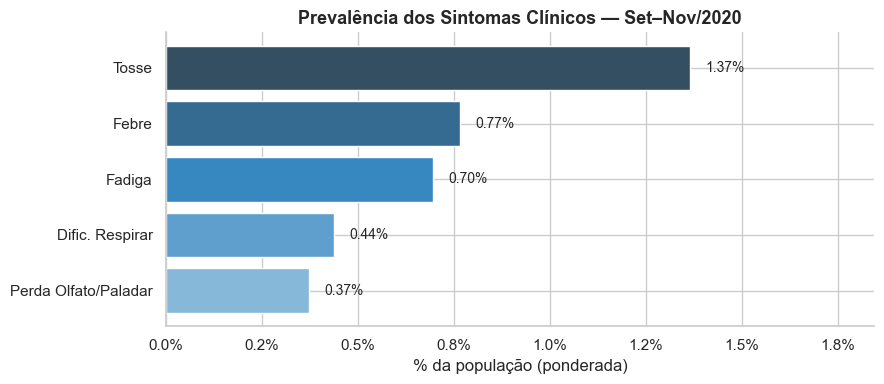

             sintoma      pct
Perda Olfato/Paladar 0.371902
     Dific. Respirar 0.438011
              Fadiga 0.696670
               Febre 0.765284
               Tosse 1.366394


In [5]:
# ── 3.1 Prevalência ponderada dos sintomas (consolidado 3 meses) ──────────
SINTOMAS = {
    'sintoma_febre':                 'Febre',
    'sintoma_tosse':                 'Tosse',
    'sintoma_dificuldade_respirar':  'Dific. Respirar',
    'sintoma_perda_olfato_paladar':  'Perda Olfato/Paladar',
    'sintoma_fadiga':                'Fadiga',
}

total_peso = base_saude.agg(F.sum('peso_amostral')).collect()[0][0]

rows_sint = []
for col, label in SINTOMAS.items():
    sim_p = base_saude.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    rows_sint.append({'sintoma': label, 'col': col, 'pct': sim_p / total_peso * 100, 'pop': sim_p})

df_sint_prev = pd.DataFrame(rows_sint).sort_values('pct')

fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette('Blues_d', len(df_sint_prev))
bars = ax.barh(df_sint_prev['sintoma'], df_sint_prev['pct'], color=palette)
for bar, row in zip(bars, df_sint_prev.itertuples()):
    ax.text(row.pct + 0.04, bar.get_y() + bar.get_height()/2, f'{row.pct:.2f}%', va='center', fontsize=10)
ax.set_xlabel('% da população (ponderada)')
ax.set_title(f'Prevalência dos Sintomas Clínicos — {PERIODO_TXT}', fontsize=13, fontweight='bold')
ax.set_xlim(0, df_sint_prev['pct'].max() * 1.35)
fmt = mticker.FormatStrFormatter('%.1f%%')
ax.xaxis.set_major_formatter(fmt)
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_01_sintomas_prevalencia.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_sint_prev[['sintoma','pct']].to_string(index=False))

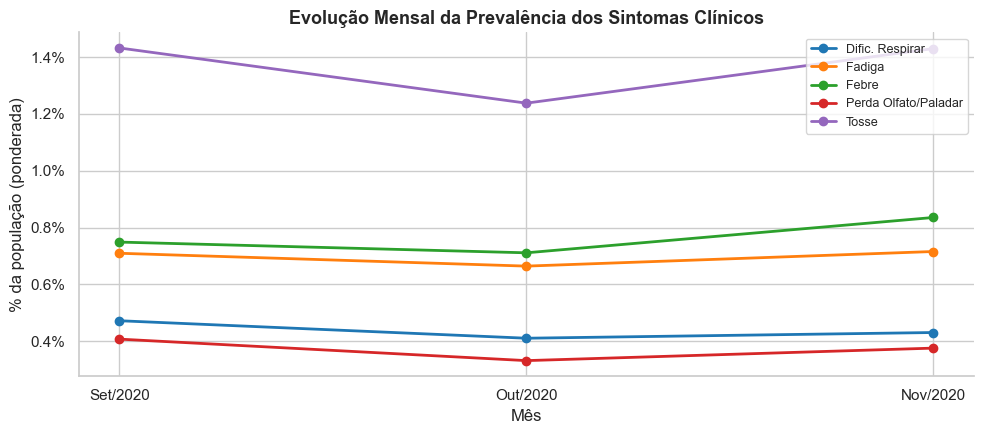

sintoma   Dific. Respirar  Fadiga  Febre  Perda Olfato/Paladar  Tosse
mes                                                                  
Set/2020             0.47    0.71   0.75                  0.41   1.43
Out/2020             0.41    0.66   0.71                  0.33   1.24
Nov/2020             0.43    0.72   0.84                  0.38   1.43


In [6]:
# ── 3.1b Evolução mês a mês da prevalência dos sintomas ──────────────────
rows_evol = []
for mes in MESES:
    sub = base_saude.filter(F.col('MES_REF') == mes)
    total_m = sub.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    for col, label in SINTOMAS.items():
        p = sub.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
        rows_evol.append({'mes': MES_LABEL[mes], 'mes_ref': mes,
                          'sintoma': label, 'pct': p/total_m*100})
df_evol = pd.DataFrame(rows_evol)

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot = df_evol.pivot(index='mes', columns='sintoma', values='pct').reindex(
    [MES_LABEL[m] for m in MESES])
for i, col in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[col], marker='o', linewidth=2,
            label=col, color=sns.color_palette('tab10')[i])
ax.set_ylabel('% da população (ponderada)')
ax.set_xlabel('Mês')
ax.set_title('Evolução Mensal da Prevalência dos Sintomas Clínicos', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(loc='upper right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_01b_sintomas_evolucao.png', dpi=120, bbox_inches='tight')
plt.show()
print(pivot.round(2).to_string())

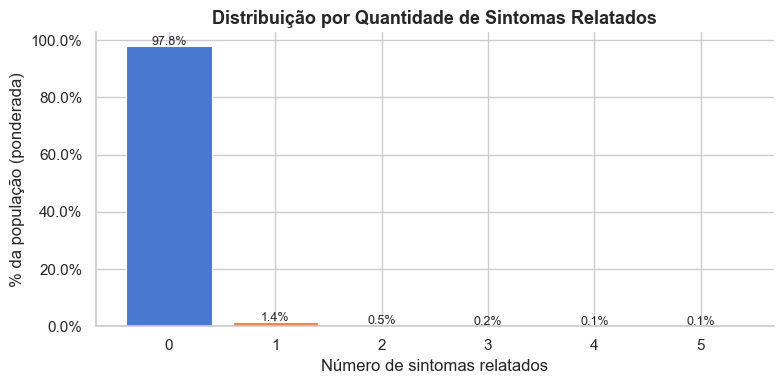

Populacao com pelo menos 1 sintoma: 2.21%


In [7]:
# ── 3.2 Distribuição de quantidade de sintomas ─────────────────────────────
qtd_df = (base_saude
    .groupBy('qtd_sintomas_relatados')
    .agg(F.sum('peso_amostral').alias('pop'))
    .toPandas()
    .sort_values('qtd_sintomas_relatados'))
qtd_df['pct'] = qtd_df['pop'] / qtd_df['pop'].sum() * 100
qtd_df['label'] = qtd_df['qtd_sintomas_relatados'].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(qtd_df['label'], qtd_df['pct'], color=sns.color_palette('muted'), edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, qtd_df['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{pct:.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Número de sintomas relatados')
ax.set_ylabel('% da população (ponderada)')
ax.set_title('Distribuição por Quantidade de Sintomas Relatados', fontsize=13, fontweight='bold')
fmt_pct(ax, 'y')
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_02_qtd_sintomas.png', dpi=120, bbox_inches='tight')
plt.show()

com_sint = qtd_df[qtd_df['qtd_sintomas_relatados'] > 0]['pct'].sum()
print(f'Populacao com pelo menos 1 sintoma: {com_sint:.2f}%')


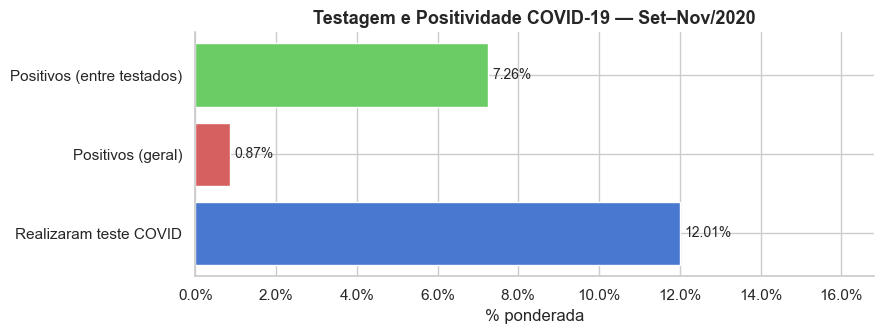

Testados: 12.01% | Positivos/testados: 7.26% | Positivos/geral: 0.87%


In [8]:
# ── 3.3 Testagem e positividade (consolidado 3 meses) ────────────────────
testados_p  = base_saude.filter(F.col('fez_teste_covid') == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
positivos_p = base_saude.filter(F.col('resultado_teste_positivo') == 'Positivo').agg(F.sum('peso_amostral')).collect()[0][0] or 0

pct_testados  = testados_p / total_peso * 100
pct_pos_geral = positivos_p / total_peso * 100
pct_pos_entre_testados = positivos_p / testados_p * 100 if testados_p > 0 else 0

dados_teste = pd.DataFrame({
    'indicador': ['Realizaram teste COVID', 'Positivos (geral)', 'Positivos (entre testados)'],
    'pct': [pct_testados, pct_pos_geral, pct_pos_entre_testados]
})

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_t = [CORES[0], CORES[3], CORES[2]]
bars = ax.barh(dados_teste['indicador'], dados_teste['pct'], color=colors_t)
for bar, pct in zip(bars, dados_teste['pct']):
    ax.text(pct + 0.1, bar.get_y() + bar.get_height()/2, f'{pct:.2f}%', va='center', fontsize=10)
ax.set_xlabel('% ponderada')
ax.set_title(f'Testagem e Positividade COVID-19 — {PERIODO_TXT}', fontsize=13, fontweight='bold')
ax.set_xlim(0, dados_teste['pct'].max() * 1.4)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_03_testagem.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Testados: {pct_testados:.2f}% | Positivos/testados: {pct_pos_entre_testados:.2f}% | Positivos/geral: {pct_pos_geral:.2f}%')

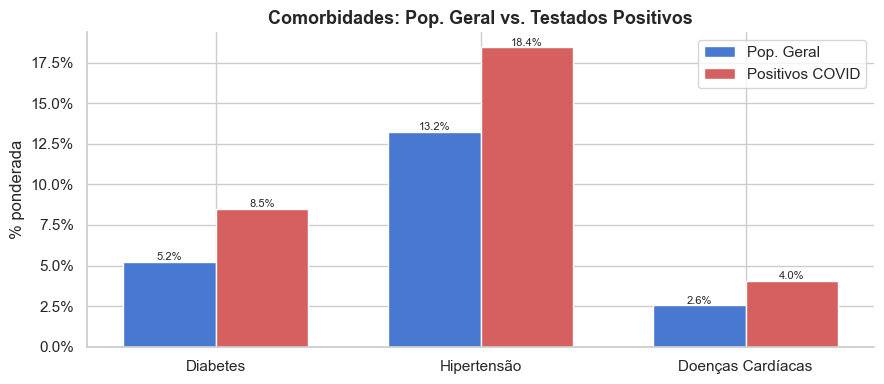

      comorbidade  Pop. Geral  Positivos COVID
         Diabetes    5.226106         8.513075
      Hipertensão   13.226149        18.440713
Doenças Cardíacas    2.555806         4.049974


In [9]:
# ── 3.4 Comorbidades: pop. geral vs. testados positivos ────────────────────
COMORBIDADES = {
    'medico_deu_diagnostico_diabetes':                    'Diabetes',
    'medico_deu_diagnostico_hipertensao':                 'Hipertensão',
    'medico_deu_diagnostico_doencas_coracao_infarto_angina': 'Doenças Cardíacas',
}

positivos_df = base_saude.filter(F.col('resultado_teste_positivo') == 'Positivo')
total_pos = positivos_df.agg(F.sum('peso_amostral')).collect()[0][0] or 1

rows_com = []
for col, label in COMORBIDADES.items():
    p_geral = base_saude.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    p_pos   = positivos_df.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    rows_com.append({'comorbidade': label, 'Pop. Geral': p_geral/total_peso*100, 'Positivos COVID': p_pos/total_pos*100})

df_com = pd.DataFrame(rows_com)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df_com))
w = 0.35
b1 = ax.bar([xi - w/2 for xi in x], df_com['Pop. Geral'], w, label='Pop. Geral', color=CORES[0])
b2 = ax.bar([xi + w/2 for xi in x], df_com['Positivos COVID'], w, label='Positivos COVID', color=CORES[3])
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.1f}%', ha='center', fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(df_com['comorbidade'])
ax.set_ylabel('% ponderada')
ax.set_title('Comorbidades: Pop. Geral vs. Testados Positivos', fontsize=13, fontweight='bold')
ax.legend()
fmt_pct(ax, 'y')
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_04_comorbidades.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_com.to_string(index=False))


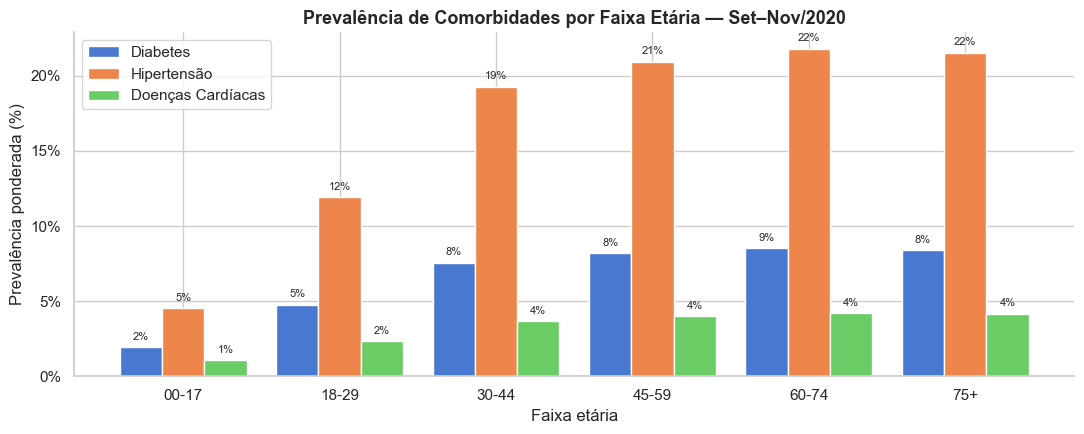

comorbidade   Diabetes  Doenças Cardíacas  Hipertensão
faixa_etaria                                          
00-17              1.9                1.1          4.5
18-29              4.8                2.3         11.9
30-44              7.6                3.7         19.3
45-59              8.2                4.0         20.9
60-74              8.5                4.2         21.8
75+                8.4                4.2         21.5


In [10]:
# ── 3.4b Comorbidades por faixa etária (consolidado 3 meses) ──────────────
ORDEM_FAIXA = ['00-17', '18-29', '30-44', '45-59', '60-74', '75+']

saude_etaria = base_saude.join(
    dim_perfil.select(CHAVE_JOIN + ['faixa_etaria']), on=CHAVE_JOIN
)

rows_com_etaria = []
for col, label in COMORBIDADES.items():
    df_g = (saude_etaria
            .groupBy('faixa_etaria')
            .agg(F.sum('peso_amostral').alias('total_p'),
                 F.sum(F.when(F.col(col) == 'Sim', F.col('peso_amostral')).otherwise(0)).alias('com_p'))
            .toPandas().dropna(subset=['faixa_etaria']))
    df_g['pct'] = df_g['com_p'] / df_g['total_p'] * 100
    df_g['comorbidade'] = label
    rows_com_etaria.append(df_g[['faixa_etaria', 'comorbidade', 'pct']])

df_com_etaria = pd.concat(rows_com_etaria, ignore_index=True)
df_com_etaria['faixa_etaria'] = pd.Categorical(df_com_etaria['faixa_etaria'], categories=ORDEM_FAIXA, ordered=True)
df_com_etaria = df_com_etaria.sort_values(['comorbidade', 'faixa_etaria'])

fig, ax = plt.subplots(figsize=(11, 4.5))
faixas_str = list(ORDEM_FAIXA)
x = range(len(faixas_str))
w = 0.27
labels_com = list(COMORBIDADES.values())
for i, label in enumerate(labels_com):
    sub = df_com_etaria[df_com_etaria['comorbidade'] == label].set_index('faixa_etaria')['pct']
    pcts = [sub.get(fx, 0) for fx in faixas_str]
    offset = (i - 1) * w
    bars = ax.bar([xi + offset for xi in x], pcts, w, label=label, color=CORES[i])
    for xi, p in zip(x, pcts):
        if p > 1:
            ax.text(xi + offset, p + 0.5, f'{p:.0f}%', ha='center', fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(faixas_str)
ax.set_xlabel('Faixa etária')
ax.set_ylabel('Prevalência ponderada (%)')
ax.set_title(f'Prevalência de Comorbidades por Faixa Etária — {PERIODO_TXT}', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_04b_comorbidades_faixa.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_com_etaria.pivot(index='faixa_etaria', columns='comorbidade', values='pct').round(1).to_string())


[Stage 174:==========================================>              (6 + 2) / 8]



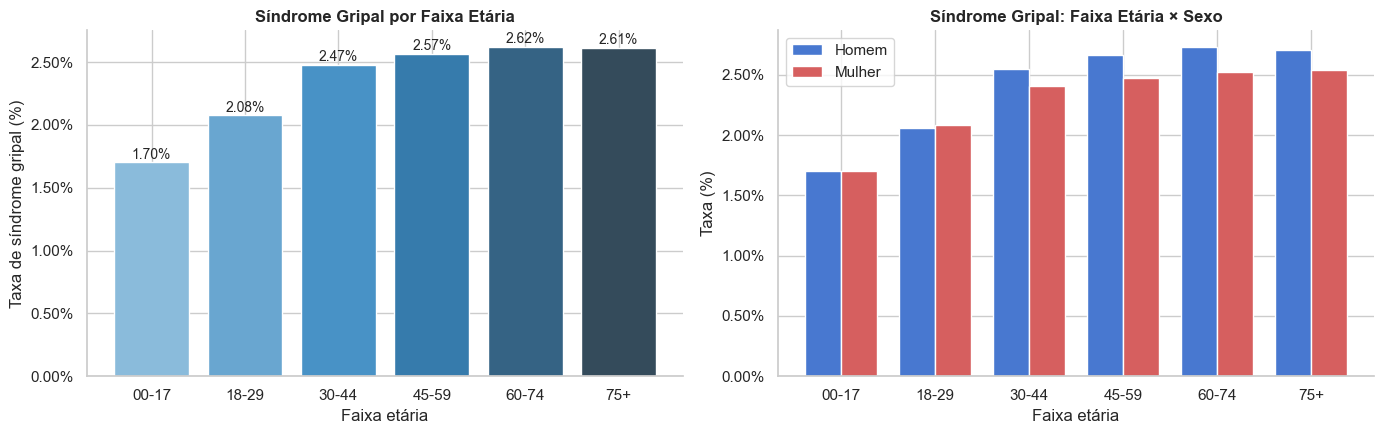

faixa_etaria     taxa
       00-17 1.702527
       18-29 2.075032
       30-44 2.474960
       45-59 2.566745
       60-74 2.620441
         75+ 2.613972


In [11]:
# ── 3.5 Perfil dos sintomáticos: faixa etária × sexo ───────────────────────
saude_perfil = base_saude.join(
    dim_perfil.select(CHAVE_JOIN + ['sexo', 'faixa_etaria', 'escolaridade']), on=CHAVE_JOIN
)

def taxa_sint(df, grupo_col):
    sint = df.filter(F.col('ind_teve_sintoma_gripal') == 1).groupBy(grupo_col).agg(F.sum('peso_amostral').alias('sint_p'))
    total_g = df.groupBy(grupo_col).agg(F.sum('peso_amostral').alias('total_p'))
    return (sint.join(total_g, on=grupo_col)
               .withColumn('taxa', F.col('sint_p') / F.col('total_p') * 100)
               .toPandas().dropna(subset=[grupo_col]))

ORDEM_FAIXA = ['00-17', '18-29', '30-44', '45-59', '60-74', '75+']

faixa_df = taxa_sint(saude_perfil, 'faixa_etaria')
faixa_df['faixa_etaria'] = pd.Categorical(faixa_df['faixa_etaria'], categories=ORDEM_FAIXA, ordered=True)
faixa_df = faixa_df.sort_values('faixa_etaria')

# Cruzamento faixa × sexo
fxs = (saude_perfil
       .filter(F.col('ind_teve_sintoma_gripal') == 1)
       .groupBy('faixa_etaria', 'sexo').agg(F.sum('peso_amostral').alias('sint_p')))
fxs_tot = saude_perfil.groupBy('faixa_etaria', 'sexo').agg(F.sum('peso_amostral').alias('tot_p'))
fxs = (fxs.join(fxs_tot, on=['faixa_etaria', 'sexo'])
           .withColumn('taxa', F.col('sint_p') / F.col('tot_p') * 100)
           .toPandas().dropna(subset=['faixa_etaria', 'sexo']))
fxs['faixa_etaria'] = pd.Categorical(fxs['faixa_etaria'], categories=ORDEM_FAIXA, ordered=True)
fxs = fxs.sort_values(['faixa_etaria', 'sexo'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

bars = axes[0].bar(faixa_df['faixa_etaria'].astype(str), faixa_df['taxa'],
                   color=sns.color_palette('Blues_d', len(faixa_df)))
for bar, t in zip(bars, faixa_df['taxa']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, f'{t:.2f}%', ha='center', fontsize=10)
axes[0].set_ylabel('Taxa de síndrome gripal (%)')
axes[0].set_xlabel('Faixa etária')
axes[0].set_title('Síndrome Gripal por Faixa Etária', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

faixas_str = list(ORDEM_FAIXA)
x = range(len(faixas_str))
w = 0.38
h = {sx: [fxs[(fxs['faixa_etaria'] == fx) & (fxs['sexo'] == sx)]['taxa'].values[0]
          if not fxs[(fxs['faixa_etaria'] == fx) & (fxs['sexo'] == sx)].empty else 0
          for fx in faixas_str] for sx in ['Homem', 'Mulher']}
axes[1].bar([xi - w/2 for xi in x], h['Homem'], w, label='Homem', color=CORES[0])
axes[1].bar([xi + w/2 for xi in x], h['Mulher'], w, label='Mulher', color=CORES[3])
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(faixas_str)
axes[1].set_xlabel('Faixa etária')
axes[1].set_ylabel('Taxa (%)')
axes[1].set_title('Síndrome Gripal: Faixa Etária × Sexo', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
axes[1].legend()
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_05_perfil_sintomaticos.png', dpi=120, bbox_inches='tight')
plt.show()
print(faixa_df[['faixa_etaria', 'taxa']].to_string(index=False))


In [12]:
# ── Spec: spec_sintomas_clinicos.csv (por mês) ───────────────────────────
rows_spec = []
for mes in MESES + ['TOTAL']:
    if mes == 'TOTAL':
        sub = base_saude
    else:
        sub = base_saude.filter(F.col('MES_REF') == mes)
    total_m = sub.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    for col, label in SINTOMAS.items():
        p = sub.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
        rows_spec.append({'mes_ref': mes, 'variavel': col, 'descricao': label,
                          'categoria': 'Sim', 'pop_ponderada': round(p),
                          'pct_ponderado': p/total_m*100, 'grupo': 'sintoma'})
    for col, label in COMORBIDADES.items():
        p = sub.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
        rows_spec.append({'mes_ref': mes, 'variavel': col, 'descricao': label,
                          'categoria': 'Sim', 'pop_ponderada': round(p),
                          'pct_ponderado': p/total_m*100, 'grupo': 'comorbidade'})
    t_p = sub.filter(F.col('fez_teste_covid') == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    pos_p = sub.filter(F.col('resultado_teste_positivo') == 'Positivo').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    rows_spec.append({'mes_ref': mes, 'variavel': 'fez_teste_covid', 'descricao': 'Realizou teste',
                      'categoria': 'Sim', 'pop_ponderada': round(t_p),
                      'pct_ponderado': t_p/total_m*100, 'grupo': 'testagem'})
    rows_spec.append({'mes_ref': mes, 'variavel': 'resultado_teste_positivo',
                      'descricao': 'Resultado Positivo', 'categoria': 'Positivo',
                      'pop_ponderada': round(pos_p), 'pct_ponderado': pos_p/total_m*100,
                      'grupo': 'testagem'})

spec_sint = pd.DataFrame(rows_spec)
spec_sint.to_csv(f'{SPECS_PATH}/spec_sintomas_clinicos.csv', index=False, encoding='utf-8')
print(f'Spec salva em {SPECS_PATH}/spec_sintomas_clinicos.csv ({len(spec_sint)} linhas)')
print(spec_sint[spec_sint['mes_ref'] == 'TOTAL'][['descricao','pct_ponderado','grupo']].to_string(index=False))

Spec salva em output/specs/spec_sintomas_clinicos.csv (40 linhas)
           descricao  pct_ponderado       grupo
               Febre       0.765284     sintoma
               Tosse       1.366394     sintoma
     Dific. Respirar       0.438011     sintoma
Perda Olfato/Paladar       0.371902     sintoma
              Fadiga       0.696670     sintoma
            Diabetes       5.226106 comorbidade
         Hipertensão      13.226149 comorbidade
   Doenças Cardíacas       2.555806 comorbidade
      Realizou teste      12.007990    testagem
  Resultado Positivo       0.871182    testagem


## 4. Comportamento da População na Época da COVID-19

Analisa adesão às medidas de proteção, busca por atendimento, situação no mercado de trabalho e isolamento social.


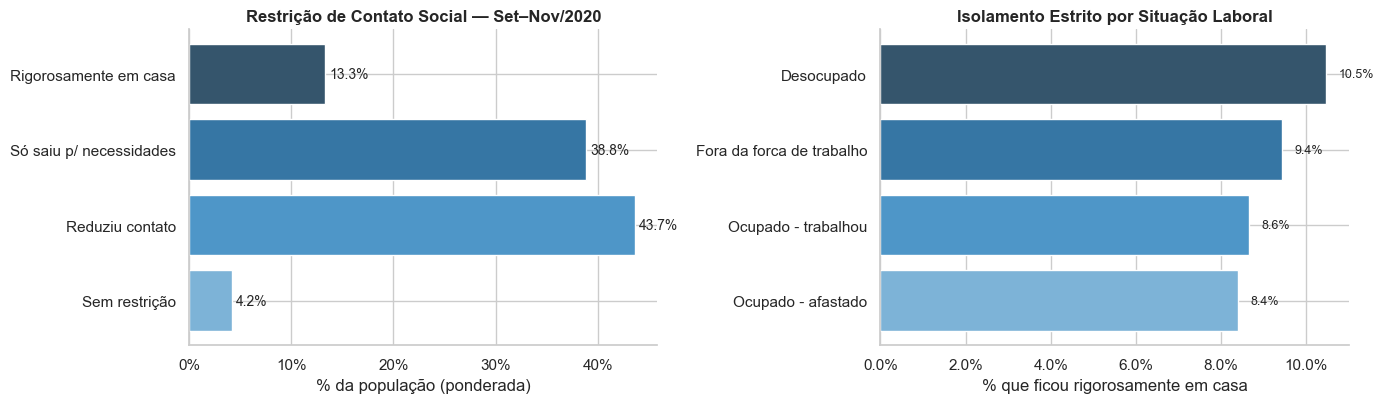

Ficou rigorosamente em casa (geral): 13.28%
            nivel_curto       pct
          Sem restrição  4.170723
        Reduziu contato 43.658933
Só saiu p/ necessidades 38.827837
  Rigorosamente em casa 13.342508


In [13]:
# ── 4.1 Restrição de contato social por situação no mercado de trabalho ──
# A PNAD COVID não mede uso de máscara. A variável comportamental é
# `restricao_contato_pessoas_pandemia` (4 níveis), em base_saude.

ORDEM_RESTR = [
    'Não fez restrição, levou vida normal como antes da pandemia',
    'Reduziu o contato com as pessoas, mas continuou saindo de casa para trabalho ou atividades não essenciais e/ou recebendo visitas',
    'Ficou em casa e só saiu em caso de necessidade básica',
    'Ficou rigorosamente em casa',
]
LABELS_RESTR_CURTO = {
    ORDEM_RESTR[0]: 'Sem restrição',
    ORDEM_RESTR[1]: 'Reduziu contato',
    ORDEM_RESTR[2]: 'Só saiu p/ necessidades',
    ORDEM_RESTR[3]: 'Rigorosamente em casa',
}

# % rigorosamente em casa na população geral (proxy de adesão máxima ao isolamento)
total_peso_s = base_saude.agg(F.sum('peso_amostral')).collect()[0][0]
peso_rigoroso = (base_saude
    .filter(F.col('restricao_contato_pessoas_pandemia') == 'Ficou rigorosamente em casa')
    .agg(F.sum('peso_amostral')).collect()[0][0]) or 0
pct_rigoroso_geral = peso_rigoroso / total_peso_s * 100

# Distribuição geral dos 4 níveis (ponderada)
restr_geral = (base_saude
    .filter(F.col('restricao_contato_pessoas_pandemia').isin(ORDEM_RESTR))
    .groupBy('restricao_contato_pessoas_pandemia')
    .agg(F.sum('peso_amostral').alias('pop')).toPandas())
restr_geral['pct'] = restr_geral['pop'] / restr_geral['pop'].sum() * 100
restr_geral['nivel_curto'] = restr_geral['restricao_contato_pessoas_pandemia'].map(LABELS_RESTR_CURTO)
restr_geral['ordem'] = restr_geral['restricao_contato_pessoas_pandemia'].map({n:i for i,n in enumerate(ORDEM_RESTR)})
restr_geral = restr_geral.sort_values('ordem')

# Cruzamento com situação no mercado de trabalho (via join saude × comp)
restr_trab = (base_saude
    .select(CHAVE_JOIN + ['restricao_contato_pessoas_pandemia', 'peso_amostral'])
    .join(base_comp.select(CHAVE_JOIN + ['situacao_mercado_trabalho']), on=CHAVE_JOIN)
    .filter(~F.col('situacao_mercado_trabalho').isin(['Nao se aplica']))
    .filter(F.col('restricao_contato_pessoas_pandemia').isin(ORDEM_RESTR))
    .groupBy('situacao_mercado_trabalho', 'restricao_contato_pessoas_pandemia')
    .agg(F.sum('peso_amostral').alias('pop'))
    .toPandas())
total_por_trab_r = restr_trab.groupby('situacao_mercado_trabalho')['pop'].sum().rename('total')
restr_trab = restr_trab.merge(total_por_trab_r, on='situacao_mercado_trabalho')
restr_trab['pct'] = restr_trab['pop'] / restr_trab['total'] * 100
# Foca em "Ficou rigorosamente em casa" por situação
rig_trab = restr_trab[restr_trab['restricao_contato_pessoas_pandemia'] == 'Ficou rigorosamente em casa'].sort_values('pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# (a) Distribuição geral dos 4 níveis
axes[0].barh(restr_geral['nivel_curto'], restr_geral['pct'],
             color=sns.color_palette('Blues_d', len(restr_geral)))
for bar, pct in zip(axes[0].patches, restr_geral['pct']):
    axes[0].text(pct + 0.4, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('% da população (ponderada)')
axes[0].set_title(f'Restrição de Contato Social — {PERIODO_TXT}', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# (b) % rigorosamente em casa por situação no mercado
axes[1].barh(rig_trab['situacao_mercado_trabalho'], rig_trab['pct'],
             color=sns.color_palette('Blues_d', len(rig_trab)))
for bar, pct in zip(axes[1].patches, rig_trab['pct']):
    axes[1].text(pct + 0.3, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('% que ficou rigorosamente em casa')
axes[1].set_title('Isolamento Estrito por Situação Laboral', fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_06_restricao_contato.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Ficou rigorosamente em casa (geral): {pct_rigoroso_geral:.2f}%')
print(restr_geral[['nivel_curto','pct']].to_string(index=False))

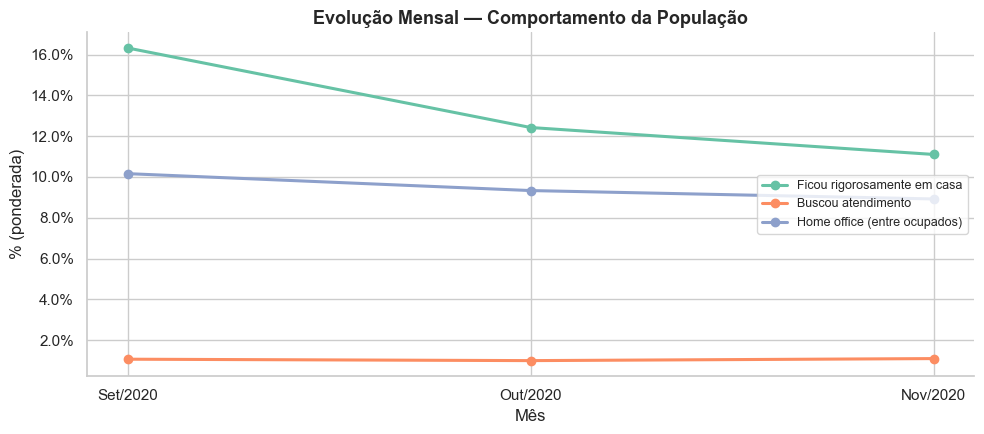

          Ficou rigorosamente em casa  Buscou atendimento  Home office (entre ocupados)
mes                                                                                    
Set/2020                        16.32                1.07                         10.16
Out/2020                        12.42                1.00                          9.33
Nov/2020                        11.10                1.10                          8.92


In [14]:
# ── 4.1b Evolução mês a mês: isolamento, atendimento, home office ───────
rows_comp_evol = []
for mes in MESES:
    sub_s = base_saude.filter(F.col('MES_REF') == mes)
    sub_c = base_comp.filter(F.col('MES_REF') == mes)
    t_s = sub_s.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    t_c = sub_c.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    rigoroso = (sub_s
        .filter(F.col('restricao_contato_pessoas_pandemia') == 'Ficou rigorosamente em casa')
        .agg(F.sum('peso_amostral')).collect()[0][0]) or 0
    atend = (sub_c.filter(F.col('buscou_atendimento_saude') == 'Sim')
                .agg(F.sum('peso_amostral')).collect()[0][0]) or 0
    ocup = sub_c.filter(F.col('trabalhou_na_semana') == 'Sim')
    t_ocup = ocup.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    ho = ocup.filter(F.col('fez_home_office') == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    rows_comp_evol.append({'mes': MES_LABEL[mes], 'mes_ref': mes,
                           'Ficou rigorosamente em casa': rigoroso/t_s*100,
                           'Buscou atendimento': atend/t_c*100,
                           'Home office (entre ocupados)': ho/t_ocup*100})

df_comp_evol = pd.DataFrame(rows_comp_evol).set_index('mes')[
    ['Ficou rigorosamente em casa', 'Buscou atendimento', 'Home office (entre ocupados)']]

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, col in enumerate(df_comp_evol.columns):
    ax.plot(df_comp_evol.index, df_comp_evol[col], marker='o', linewidth=2.2,
            label=col, color=sns.color_palette('Set2')[i])
ax.set_ylabel('% (ponderada)')
ax.set_xlabel('Mês')
ax.set_title('Evolução Mensal — Comportamento da População', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(loc='center right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_06b_comportamento_evolucao.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_comp_evol.round(2).to_string())

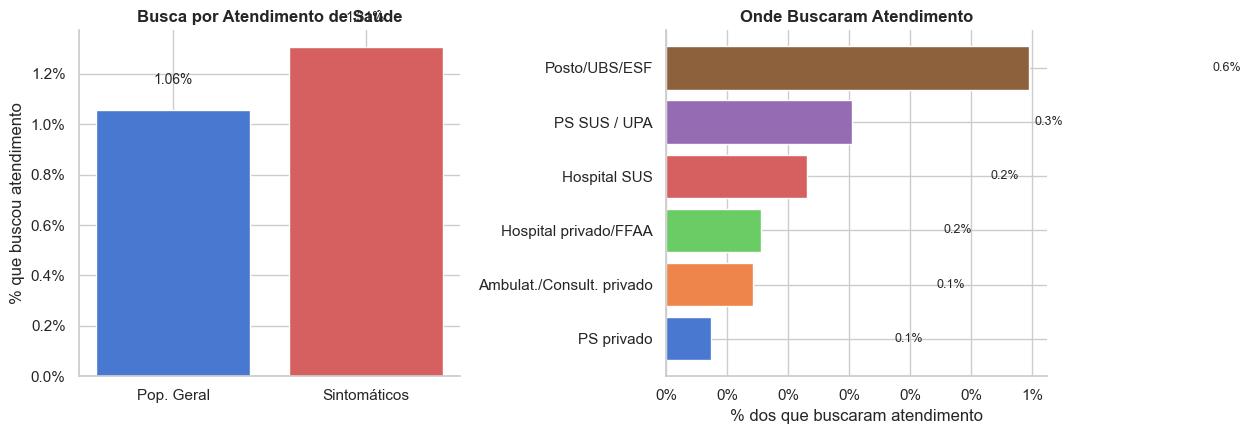

Buscou atendimento (geral): 1.06% | Sintomáticos: 1.31%
                    local      pct
               PS privado 0.073589
Ambulat./Consult. privado 0.142405
    Hospital privado/FFAA 0.155309
             Hospital SUS 0.231482
             PS SUS / UPA 0.304031
            Posto/UBS/ESF 0.594736


In [15]:
# ── 4.2 Busca por atendimento entre sintomáticos ───────────────────────
sint_comp = base_comp.join(
    base_saude.select(CHAVE_JOIN + ['ind_teve_sintoma_gripal']), on=CHAVE_JOIN
)
sint_filtro = sint_comp.filter(F.col('ind_teve_sintoma_gripal') == 1)

pct_atend_sint = pct_pond(sint_filtro, 'buscou_atendimento_saude', 'Sim')
pct_atend_geral = pct_pond(base_comp, 'buscou_atendimento_saude', 'Sim')

# Onde buscaram atendimento (entre quem buscou) — usar local_buscou_atendimento_*
# (variáveis B0041-B0046, em base_saude, corretamente nomeadas no dicionário).
locais = {
    'local_buscou_atendimento_posto_saude_unidade_basica_saude': 'Posto/UBS/ESF',
    'local_buscou_atendimento_pronto_socorro_sus_upa':           'PS SUS / UPA',
    'local_buscou_atendimento_hospital_sus':                     'Hospital SUS',
    'local_buscou_atendimento_ambulatorio_consultorio_privado':  'Ambulat./Consult. privado',
    'local_buscou_atendimento_pronto_socorro_privado_ligado':    'PS privado',
    'local_buscou_atendimento_hospital_privado_ligado_forcas':   'Hospital privado/FFAA',
}

# As colunas estão em base_saude; cruzamos com quem buscou atendimento via join.
buscaram_ids = (base_comp.filter(F.col('buscou_atendimento_saude') == 'Sim')
                          .select(CHAVE_JOIN + ['peso_amostral']))
buscaram_saude = buscaram_ids.join(
    base_saude.select(CHAVE_JOIN + list(locais.keys())), on=CHAVE_JOIN
)
total_buscaram = buscaram_saude.agg(F.sum('peso_amostral')).collect()[0][0] or 1

rows_loc = []
for col, label in locais.items():
    if col in buscaram_saude.columns:
        p = buscaram_saude.filter(F.col(col) == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
        rows_loc.append({'local': label, 'pct': p/total_buscaram*100})
df_locais = pd.DataFrame(rows_loc).sort_values('pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dados_bar = pd.DataFrame({'grupo': ['Pop. Geral', 'Sintomáticos'],
                           'pct':  [pct_atend_geral, pct_atend_sint]})
bars = axes[0].bar(dados_bar['grupo'], dados_bar['pct'], color=[CORES[0], CORES[3]])
for bar, pct in zip(bars, dados_bar['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{pct:.2f}%', ha='center', fontsize=10)
axes[0].set_ylabel('% que buscou atendimento')
axes[0].set_title('Busca por Atendimento de Saúde', fontsize=12, fontweight='bold')
fmt_pct(axes[0], 'y')

axes[1].barh(df_locais['local'], df_locais['pct'], color=sns.color_palette('muted'))
for bar, pct in zip(axes[1].patches, df_locais['pct']):
    axes[1].text(pct + 0.3, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('% dos que buscaram atendimento')
axes[1].set_title('Onde Buscaram Atendimento', fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_07_atendimento.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Buscou atendimento (geral): {pct_atend_geral:.2f}% | Sintomáticos: {pct_atend_sint:.2f}%')
print(df_locais.to_string(index=False))

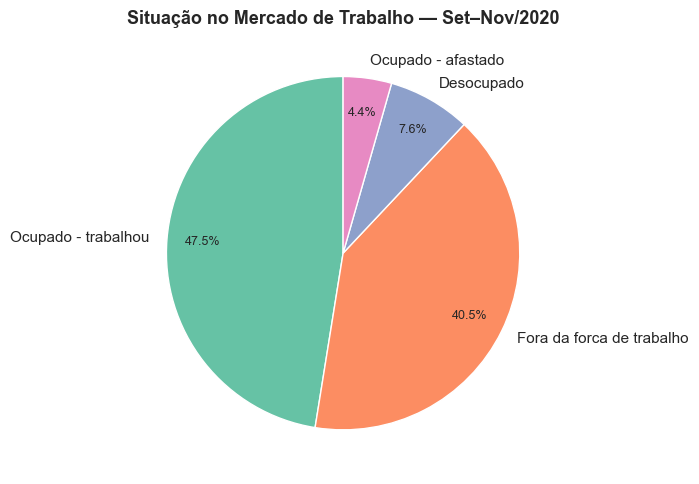

situacao_mercado_trabalho       pct
      Ocupado - trabalhou 47.465453
Fora da forca de trabalho 40.523932
               Desocupado  7.584659
       Ocupado - afastado  4.425955


In [16]:
# ── 4.3 Situação no mercado de trabalho (consolidado 3 meses) ────────────
trab_df = dist_pond(base_comp.filter(F.col('situacao_mercado_trabalho') != 'Nao se aplica'),
                    'situacao_mercado_trabalho')
trab_df = trab_df.sort_values('pct', ascending=False)

CORES_TRAB = sns.color_palette('Set2', len(trab_df))
fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(trab_df['pct'], labels=trab_df['situacao_mercado_trabalho'],
                                   autopct='%1.1f%%', colors=CORES_TRAB,
                                   startangle=90, pctdistance=0.8)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f'Situação no Mercado de Trabalho — {PERIODO_TXT}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_08_mercado_trabalho.png', dpi=120, bbox_inches='tight')
plt.show()
print(trab_df[['situacao_mercado_trabalho','pct']].to_string(index=False))


[Stage 432:=================================================>       (7 + 1) / 8]



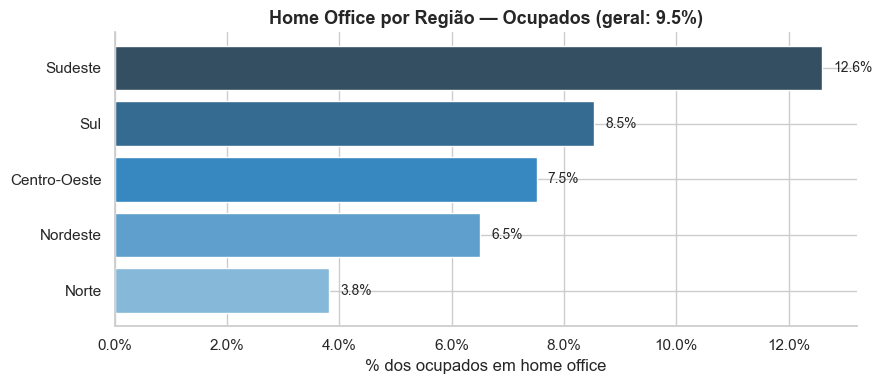

      regiao       pct
       Norte  3.820659
    Nordeste  6.507595
Centro-Oeste  7.509875
         Sul  8.535851
     Sudeste 12.590464


In [17]:
# ── 4.4 Adesão ao home office por região ────────────────────────────────────
ocupados = base_comp.filter(F.col('trabalhou_na_semana') == 'Sim')
comp_loc  = ocupados.join(dim_loc.select(CHAVE_JOIN + ['regiao']), on=CHAVE_JOIN)

home_reg = (comp_loc
    .groupBy('regiao', 'fez_home_office')
    .agg(F.sum('peso_amostral').alias('pop'))
    .toPandas())
total_reg = home_reg.groupby('regiao')['pop'].sum().rename('total')
home_reg  = home_reg.merge(total_reg, on='regiao')
home_reg['pct'] = home_reg['pop'] / home_reg['total'] * 100
home_sim  = home_reg[home_reg['fez_home_office'] == 'Sim'].sort_values('pct', ascending=True)

pct_home_geral = pct_pond(ocupados, 'fez_home_office', 'Sim')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(home_sim['regiao'], home_sim['pct'], color=sns.color_palette('Blues_d', len(home_sim)))
for bar, pct in zip(bars, home_sim['pct']):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% dos ocupados em home office')
ax.set_title(f'Home Office por Região — Ocupados (geral: {pct_home_geral:.1f}%)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_09_home_office.png', dpi=120, bbox_inches='tight')
plt.show()
print(home_sim[['regiao','pct']].to_string(index=False))


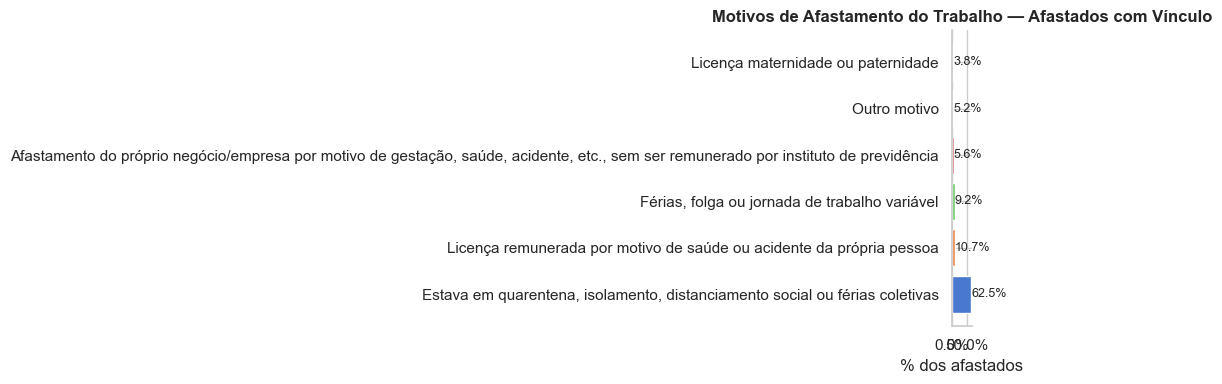

Spec salva em output/specs/spec_comportamento.csv (20 linhas)
                        descricao  pct_ponderado
      Ficou rigorosamente em casa      13.281516
       Buscou atendimento (geral)       1.058567
Buscou atendimento (sintomáticos)       1.307112
     Home office (entre ocupados)       9.466248
              Ocupado - trabalhou      47.465453
        Fora da forca de trabalho      40.523932
                       Desocupado       7.584659
               Ocupado - afastado       4.425955


In [18]:
# ── 4.5 Motivo de afastamento do trabalho ───────────────────────────────────
afastados = base_comp.filter(F.col('estava_afastado_com_vinculo') == 'Sim')
motivo_df = dist_pond(afastados, 'motivo_afastamento').head(6)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(motivo_df['motivo_afastamento'], motivo_df['pct'],
               color=sns.color_palette('muted', len(motivo_df)))
for bar, pct in zip(bars, motivo_df['pct']):
    ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% dos afastados')
ax.set_title('Motivos de Afastamento do Trabalho — Afastados com Vínculo', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_10_motivo_afastamento.png', dpi=120, bbox_inches='tight')
plt.show()

# Spec comportamento — por mês + total. KPI principal:
# % "Ficou rigorosamente em casa" (vem da base_saude, variável restricao_contato_pessoas_pandemia).
rows_comp_spec = []
for mes in MESES + ['TOTAL']:
    sub_s = base_saude if mes == 'TOTAL' else base_saude.filter(F.col('MES_REF') == mes)
    sub_c = base_comp  if mes == 'TOTAL' else base_comp.filter(F.col('MES_REF') == mes)
    t_s = sub_s.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    p_rig = (sub_s
        .filter(F.col('restricao_contato_pessoas_pandemia') == 'Ficou rigorosamente em casa')
        .agg(F.sum('peso_amostral')).collect()[0][0]) or 0
    p_atend = pct_pond(sub_c, 'buscou_atendimento_saude', 'Sim')
    sub_sint_join = sub_c.join(
        sub_s.select(CHAVE_JOIN + ['ind_teve_sintoma_gripal']), on=CHAVE_JOIN)
    p_atend_sint = pct_pond(sub_sint_join.filter(F.col('ind_teve_sintoma_gripal') == 1),
                            'buscou_atendimento_saude', 'Sim')
    sub_ocup = sub_c.filter(F.col('trabalhou_na_semana') == 'Sim')
    p_home = pct_pond(sub_ocup, 'fez_home_office', 'Sim')
    rows_comp_spec.extend([
        {'mes_ref': mes, 'variavel': 'restricao_contato_pessoas_pandemia',
         'descricao': 'Ficou rigorosamente em casa',
         'pct_ponderado': p_rig/t_s*100, 'grupo': 'protecao'},
        {'mes_ref': mes, 'variavel': 'buscou_atendimento_saude_geral',
         'descricao': 'Buscou atendimento (geral)',
         'pct_ponderado': p_atend, 'grupo': 'atendimento'},
        {'mes_ref': mes, 'variavel': 'buscou_atendimento_saude_sintomaticos',
         'descricao': 'Buscou atendimento (sintomáticos)',
         'pct_ponderado': p_atend_sint, 'grupo': 'atendimento'},
        {'mes_ref': mes, 'variavel': 'fez_home_office',
         'descricao': 'Home office (entre ocupados)',
         'pct_ponderado': p_home, 'grupo': 'trabalho'},
    ])
    if mes == 'TOTAL':
        for _, row in trab_df.iterrows():
            rows_comp_spec.append({'mes_ref': mes, 'variavel': 'situacao_mercado_trabalho',
                                   'descricao': row['situacao_mercado_trabalho'],
                                   'pct_ponderado': row['pct'], 'grupo': 'mercado_trabalho'})

spec_comp = pd.DataFrame(rows_comp_spec)
spec_comp.to_csv(f'{SPECS_PATH}/spec_comportamento.csv', index=False, encoding='utf-8')
print(f'Spec salva em {SPECS_PATH}/spec_comportamento.csv ({len(spec_comp)} linhas)')
print(spec_comp[spec_comp['mes_ref'] == 'TOTAL'][['descricao','pct_ponderado']].to_string(index=False))

## 5. Características Econômicas da Sociedade

Analisa a distribuição de renda, cobertura dos auxílios governamentais, sobreposição de benefícios e impacto econômico da pandemia.


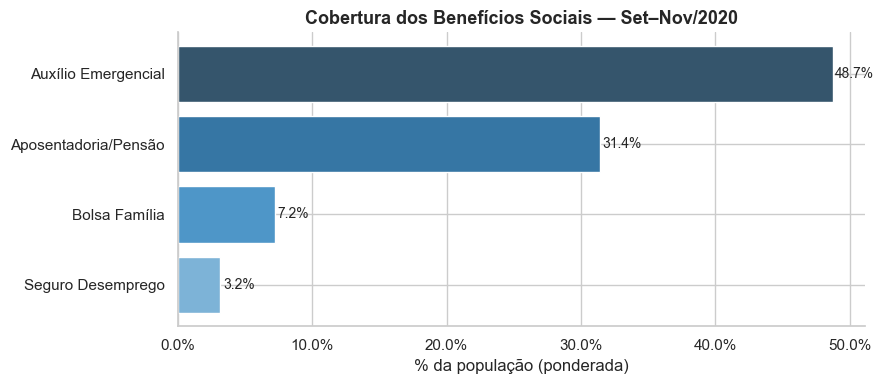

Auxílio emergencial: 48.7% | Bolsa Família: 7.2% | Seguro desemprego: 3.2%


In [19]:
# ── 5.1 Cobertura dos benefícios sociais (consolidado 3 meses) ───────────
total_eco = base_eco.agg(F.sum('peso_amostral')).collect()[0][0]

pct_aux   = pct_pond(base_eco, 'recebeu_auxilio_emergencial', 'Sim')
pct_bf    = pct_pond(base_eco, 'recebeu_bolsa_familia',       'Sim')
pct_sd    = pct_pond(base_eco, 'recebeu_seguro_desemprego',   'Sim')
pct_aposen = pct_pond(base_eco, 'recebeu_aposentadoria_pensao', 'Sim')

beneficios = pd.DataFrame({
    'beneficio': ['Auxílio Emergencial', 'Aposentadoria/Pensão', 'Bolsa Família', 'Seguro Desemprego'],
    'pct': [pct_aux, pct_aposen, pct_bf, pct_sd]
}).sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(beneficios['beneficio'], beneficios['pct'],
               color=sns.color_palette('Blues_d', len(beneficios)))
for bar, pct in zip(bars, beneficios['pct']):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% da população (ponderada)')
ax.set_title(f'Cobertura dos Benefícios Sociais — {PERIODO_TXT}', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_11_beneficios.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Auxílio emergencial: {pct_aux:.1f}% | Bolsa Família: {pct_bf:.1f}% | Seguro desemprego: {pct_sd:.1f}%')

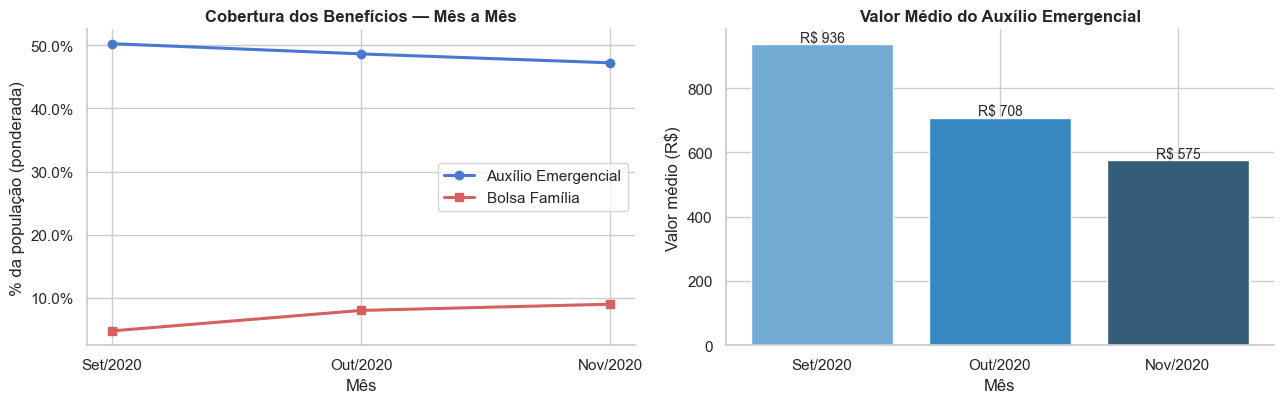

     mes mes_ref  pct_auxilio  pct_bf  valor_medio_auxilio
Set/2020 2020-09        50.27    4.73               935.98
Out/2020 2020-10        48.65    7.98               708.38
Nov/2020 2020-11        47.23    8.97               574.98


In [20]:
# ── 5.1b Evolução mês a mês: cobertura e valor médio do Auxílio Emergencial ──
rows_eco_evol = []
for mes in MESES:
    sub = base_eco.filter(F.col('MES_REF') == mes)
    t = sub.agg(F.sum('peso_amostral')).collect()[0][0] or 1
    aux_p = sub.filter(F.col('recebeu_auxilio_emergencial') == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    bf_p = sub.filter(F.col('recebeu_bolsa_familia') == 'Sim').agg(F.sum('peso_amostral')).collect()[0][0] or 0
    valor_aux = (sub.filter((F.col('recebeu_auxilio_emergencial') == 'Sim') &
                            F.col('valor_auxilio_emergencial').isNotNull())
        .agg((F.sum(F.col('valor_auxilio_emergencial') * F.col('peso_amostral')) /
              F.sum('peso_amostral')).alias('v')).collect()[0][0]) or 0
    rows_eco_evol.append({'mes': MES_LABEL[mes], 'mes_ref': mes,
                          'pct_auxilio': aux_p/t*100, 'pct_bf': bf_p/t*100,
                          'valor_medio_auxilio': valor_aux})
df_eco_evol = pd.DataFrame(rows_eco_evol)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.plot(df_eco_evol['mes'], df_eco_evol['pct_auxilio'], marker='o', linewidth=2.2,
         label='Auxílio Emergencial', color=CORES[0])
ax1.plot(df_eco_evol['mes'], df_eco_evol['pct_bf'], marker='s', linewidth=2.2,
         label='Bolsa Família', color=CORES[3])
ax1.set_ylabel('% da população (ponderada)')
ax1.set_xlabel('Mês')
ax1.set_title('Cobertura dos Benefícios — Mês a Mês', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.legend()

ax2.bar(df_eco_evol['mes'], df_eco_evol['valor_medio_auxilio'],
        color=sns.color_palette('Blues_d', 3))
for i, v in enumerate(df_eco_evol['valor_medio_auxilio']):
    ax2.text(i, v + 8, f'R$ {v:.0f}', ha='center', fontsize=10)
ax2.set_ylabel('Valor médio (R$)')
ax2.set_xlabel('Mês')
ax2.set_title('Valor Médio do Auxílio Emergencial', fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_11b_beneficios_evolucao.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_eco_evol.round(2).to_string(index=False))

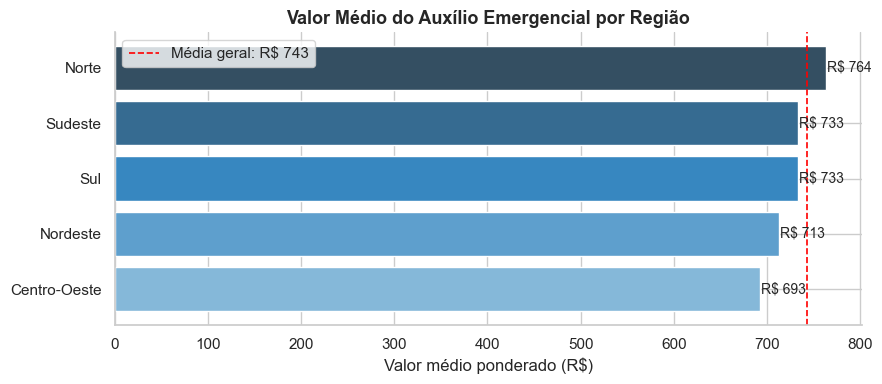

Valor médio geral: R$ 743.47
      regiao  valor_medio_pond
Centro-Oeste        692.956303
    Nordeste        712.828953
         Sul        732.906117
     Sudeste        733.114753
       Norte        763.502631


In [21]:
# ── 5.2 Valor médio ponderado do auxílio emergencial por região ─────────────
eco_loc = (base_eco
    .filter((F.col('recebeu_auxilio_emergencial') == 'Sim') & F.col('valor_auxilio_emergencial').isNotNull())
    .join(dim_loc.select(CHAVE_JOIN + ['regiao']), on=CHAVE_JOIN))

valor_reg = (eco_loc
    .groupBy('regiao')
    .agg(
        (F.sum(F.col('valor_auxilio_emergencial') * F.col('peso_amostral')) /
         F.sum('peso_amostral')).alias('valor_medio_pond')
    )
    .toPandas()
    .sort_values('valor_medio_pond', ascending=True))

valor_geral = (base_eco
    .filter((F.col('recebeu_auxilio_emergencial') == 'Sim') & F.col('valor_auxilio_emergencial').isNotNull())
    .agg((F.sum(F.col('valor_auxilio_emergencial') * F.col('peso_amostral')) / F.sum('peso_amostral')).alias('v'))
    .collect()[0][0])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(valor_reg['regiao'], valor_reg['valor_medio_pond'],
               color=sns.color_palette('Blues_d', len(valor_reg)))
for bar, val in zip(bars, valor_reg['valor_medio_pond']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'R$ {val:.0f}', va='center', fontsize=10)
ax.axvline(valor_geral, color='red', linestyle='--', linewidth=1.2, label=f'Média geral: R$ {valor_geral:.0f}')
ax.set_xlabel('Valor médio ponderado (R$)')
ax.set_title('Valor Médio do Auxílio Emergencial por Região', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_12_auxilio_regiao.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Valor médio geral: R$ {valor_geral:.2f}')
print(valor_reg.to_string(index=False))


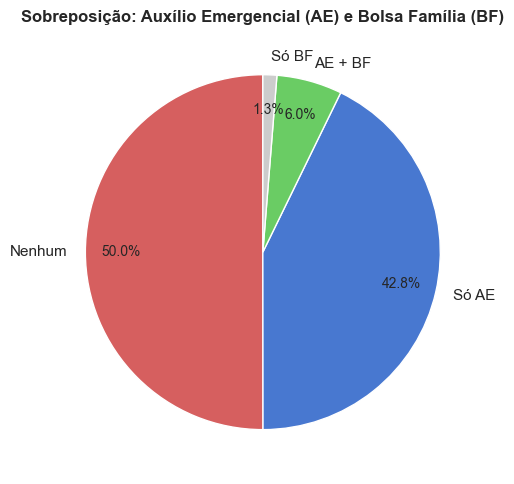

  grupo       pct
 Nenhum 50.016642
  Só AE 42.754527
AE + BF  5.962099
  Só BF  1.266732


In [22]:
# ── 5.3 Sobreposição Bolsa Família + Auxílio Emergencial ────────────────────
overlap = (base_eco
    .withColumn('grupo',
        F.when((F.col('recebeu_auxilio_emergencial') == 'Sim') & (F.col('recebeu_bolsa_familia') == 'Sim'), 'AE + BF')
         .when((F.col('recebeu_auxilio_emergencial') == 'Sim') & (F.col('recebeu_bolsa_familia') != 'Sim'), 'Só AE')
         .when((F.col('recebeu_auxilio_emergencial') != 'Sim') & (F.col('recebeu_bolsa_familia') == 'Sim'), 'Só BF')
         .otherwise('Nenhum'))
    .groupBy('grupo').agg(F.sum('peso_amostral').alias('pop'))
    .toPandas())
overlap['pct'] = overlap['pop'] / overlap['pop'].sum() * 100
overlap = overlap.sort_values('pct', ascending=False)

CORES_OVL = [CORES[3], CORES[0], CORES[2], '#cccccc']
fig, ax = plt.subplots(figsize=(8, 5))
wedges, _, autotexts = ax.pie(overlap['pct'], labels=overlap['grupo'],
                               autopct='%1.1f%%', colors=CORES_OVL,
                               startangle=90, pctdistance=0.8)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Sobreposição: Auxílio Emergencial (AE) e Bolsa Família (BF)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_13_overlap_beneficios.png', dpi=120, bbox_inches='tight')
plt.show()
print(overlap[['grupo','pct']].to_string(index=False))


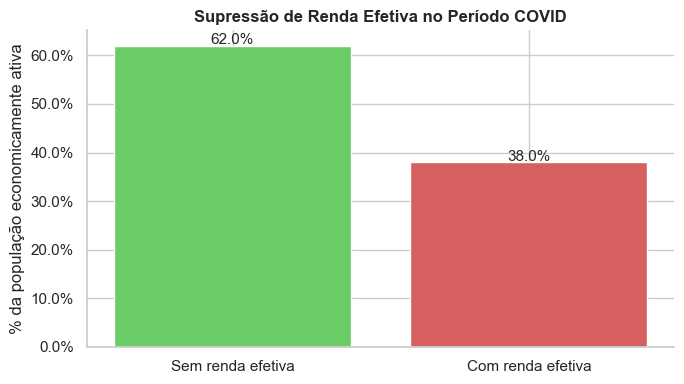

Com renda efetiva: 38.0% | Sem renda efetiva: 62.0%


In [23]:
# ── 5.4 Supressão de renda efetiva pela pandemia ────────────────────────────
renda_df = dist_pond(base_eco, 'ind_tem_renda_efetiva')
renda_df['label'] = renda_df['ind_tem_renda_efetiva'].map({1: 'Com renda efetiva', 0: 'Sem renda efetiva'})

pct_sem_renda = renda_df[renda_df['ind_tem_renda_efetiva'] == 0]['pct'].values[0] if 0 in renda_df['ind_tem_renda_efetiva'].values else 0
pct_com_renda = renda_df[renda_df['ind_tem_renda_efetiva'] == 1]['pct'].values[0] if 1 in renda_df['ind_tem_renda_efetiva'].values else 0

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(renda_df['label'], renda_df['pct'], color=[CORES[2], CORES[3]])
for bar, pct in zip(bars, renda_df['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{pct:.1f}%', ha='center', fontsize=11)
ax.set_ylabel('% da população economicamente ativa')
ax.set_title('Supressão de Renda Efetiva no Período COVID', fontsize=12, fontweight='bold')
fmt_pct(ax, 'y')
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_14_renda_suprimida.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Com renda efetiva: {pct_com_renda:.1f}% | Sem renda efetiva: {pct_sem_renda:.1f}%')


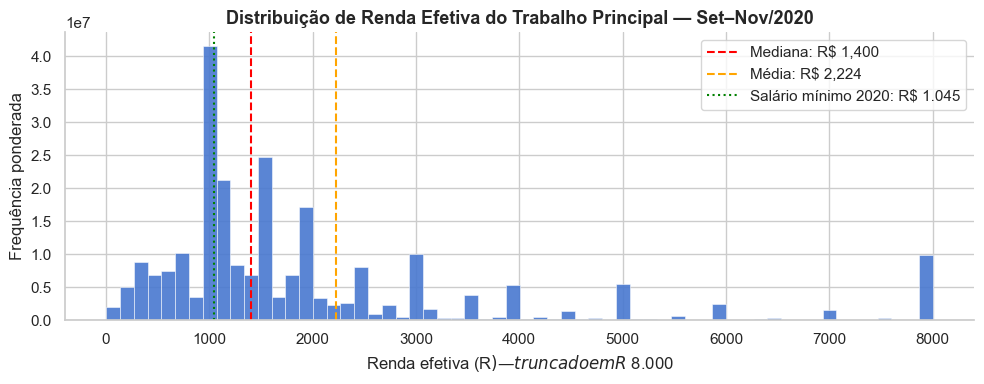

Mediana ponderada: R$ 1,400 | Média ponderada: R$ 2,224



Spec salva em output/specs/spec_economico.csv (31 linhas)
                      descricao  pct_ponderado  valor_medio_ponderado
    Recebeu Auxílio Emergencial      48.716626                    NaN
          Recebeu Bolsa Família       7.228831                    NaN
      Recebeu Seguro Desemprego       3.162884                    NaN
Valor médio Auxílio Emergencial            NaN             743.473756
       Sem renda efetiva no mês      62.036604                    NaN
          Mediana renda efetiva            NaN            1400.000000
            Média renda efetiva            NaN            2224.055086
                         Nenhum      50.016642                    NaN
                          Só AE      42.754527                    NaN
                        AE + BF       5.962099                    NaN
                          Só BF       1.266732                    NaN
   Auxílio médio - Centro-Oeste            NaN             692.956303
       Auxílio médio - Nordeste

In [24]:
# ── 5.5 Distribuição de renda efetiva do trabalho principal (3 meses) ──────
renda_vals = (base_eco
    .filter(F.col('renda_efetiva_trabalho_principal') > 0)
    .select('renda_efetiva_trabalho_principal', 'peso_amostral')
    .toPandas())

def mediana_pond(vals, pesos):
    df = pd.DataFrame({'v': vals, 'p': pesos}).sort_values('v')
    df['p_cum'] = df['p'].cumsum()
    total = df['p'].sum()
    return df[df['p_cum'] >= total/2]['v'].iloc[0]

med_pond = mediana_pond(renda_vals['renda_efetiva_trabalho_principal'],
                        renda_vals['peso_amostral'])
media_pond = (renda_vals['renda_efetiva_trabalho_principal'] * renda_vals['peso_amostral']).sum() / renda_vals['peso_amostral'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(renda_vals['renda_efetiva_trabalho_principal'].clip(upper=8000),
        weights=renda_vals['peso_amostral'], bins=60,
        color=CORES[0], edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(med_pond,   color='red',    linestyle='--', linewidth=1.5, label=f'Mediana: R$ {med_pond:,.0f}')
ax.axvline(media_pond, color='orange', linestyle='--', linewidth=1.5, label=f'Média: R$ {media_pond:,.0f}')
ax.axvline(1045, color='green', linestyle=':', linewidth=1.5, label='Salário mínimo 2020: R$ 1.045')
ax.set_xlabel('Renda efetiva (R$) — truncado em R$ 8.000')
ax.set_ylabel('Frequência ponderada')
ax.set_title(f'Distribuição de Renda Efetiva do Trabalho Principal — {PERIODO_TXT}',
             fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(f'{SPECS_PATH}/fig_15_renda_distribuicao.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Mediana ponderada: R$ {med_pond:,.0f} | Média ponderada: R$ {media_pond:,.0f}')

# Spec econômico — por mês + total
spec_eco_rows = []
for mes in MESES + ['TOTAL']:
    sub = base_eco if mes == 'TOTAL' else base_eco.filter(F.col('MES_REF') == mes)
    p_aux = pct_pond(sub, 'recebeu_auxilio_emergencial', 'Sim')
    p_bf = pct_pond(sub, 'recebeu_bolsa_familia', 'Sim')
    p_sd = pct_pond(sub, 'recebeu_seguro_desemprego', 'Sim')
    v_aux = (sub.filter((F.col('recebeu_auxilio_emergencial') == 'Sim') &
                        F.col('valor_auxilio_emergencial').isNotNull())
        .agg((F.sum(F.col('valor_auxilio_emergencial') * F.col('peso_amostral')) /
              F.sum('peso_amostral')).alias('v')).collect()[0][0]) or 0
    p_sem_renda = pct_pond(sub, 'ind_tem_renda_efetiva', 0)
    spec_eco_rows.extend([
        {'mes_ref': mes, 'variavel': 'recebeu_auxilio_emergencial',
         'descricao': 'Recebeu Auxílio Emergencial', 'pct_ponderado': p_aux,
         'valor_medio_ponderado': None, 'grupo': 'beneficio'},
        {'mes_ref': mes, 'variavel': 'recebeu_bolsa_familia',
         'descricao': 'Recebeu Bolsa Família', 'pct_ponderado': p_bf,
         'valor_medio_ponderado': None, 'grupo': 'beneficio'},
        {'mes_ref': mes, 'variavel': 'recebeu_seguro_desemprego',
         'descricao': 'Recebeu Seguro Desemprego', 'pct_ponderado': p_sd,
         'valor_medio_ponderado': None, 'grupo': 'beneficio'},
        {'mes_ref': mes, 'variavel': 'valor_auxilio_emergencial',
         'descricao': 'Valor médio Auxílio Emergencial', 'pct_ponderado': None,
         'valor_medio_ponderado': v_aux, 'grupo': 'renda'},
        {'mes_ref': mes, 'variavel': 'ind_tem_renda_efetiva',
         'descricao': 'Sem renda efetiva no mês', 'pct_ponderado': p_sem_renda,
         'valor_medio_ponderado': None, 'grupo': 'renda'},
    ])

# Estatísticas de renda — só TOTAL (a partir do cálculo pandas acima)
spec_eco_rows.extend([
    {'mes_ref': 'TOTAL', 'variavel': 'renda_efetiva_trabalho_principal',
     'descricao': 'Mediana renda efetiva', 'pct_ponderado': None,
     'valor_medio_ponderado': med_pond, 'grupo': 'renda'},
    {'mes_ref': 'TOTAL', 'variavel': 'renda_efetiva_trabalho_principal',
     'descricao': 'Média renda efetiva', 'pct_ponderado': None,
     'valor_medio_ponderado': media_pond, 'grupo': 'renda'},
])
# Sobreposição AE×BF + Auxílio por região — só TOTAL
for _, row in overlap.iterrows():
    spec_eco_rows.append({'mes_ref': 'TOTAL', 'variavel': 'sobreposicao_bf_ae',
                          'descricao': row['grupo'], 'pct_ponderado': row['pct'],
                          'valor_medio_ponderado': None, 'grupo': 'sobreposicao'})
for _, row in valor_reg.iterrows():
    spec_eco_rows.append({'mes_ref': 'TOTAL', 'variavel': 'valor_auxilio_regiao',
                          'descricao': f"Auxílio médio - {row['regiao']}",
                          'pct_ponderado': None,
                          'valor_medio_ponderado': row['valor_medio_pond'],
                          'grupo': 'renda_regiao'})

spec_eco = pd.DataFrame(spec_eco_rows)
spec_eco.to_csv(f'{SPECS_PATH}/spec_economico.csv', index=False, encoding='utf-8')
print(f'\nSpec salva em {SPECS_PATH}/spec_economico.csv ({len(spec_eco)} linhas)')
print(spec_eco[spec_eco['mes_ref'] == 'TOTAL'][['descricao','pct_ponderado','valor_medio_ponderado']].to_string(index=False))

## 6. Recomendações ao Hospital em Caso de Novo Surto

Com base nas três análises realizadas (set/out/nov 2020 — fase de desaceleração da primeira onda), as recomendações a seguir são **derivadas dos dados** da PNAD COVID-19.

> **Nota sobre a fonte:** a PNAD COVID **não pergunta sobre uso de máscara**. O indicador comportamental disponível é o **nível de restrição de contato social** (4 níveis: sem restrição / reduziu contato / só sai p/ necessidades / rigorosamente em casa). As recomendações de prevenção foram ajustadas para refletir esse fato.

---

### Eixo 1 — Triagem e Priorização Clínica

| Ação | Fundamentação nos dados |
|---|---|
| Priorizar triagem de pacientes com **febre + tosse combinadas** | Sintomas mais prevalentes e co-ocorrentes nos 3 meses |
| Sinalizar alto risco em pacientes com **dificuldade respiratória** | Indicador de severidade clínica imediata |
| Criar protocolo acelerado para **idosos com hipertensão ou diabetes** | Comorbidades associadas a maior positividade; prevalência cresce rapidamente após 45 anos |
| Incluir perda de olfato/paladar como critério de isolamento imediato | Sintoma altamente específico da COVID-19 |

---

### Eixo 2 — Dimensionamento de Capacidade

| Indicador | Valor observado (3 meses) | Implicação |
|---|---|---|
| Taxa de busca por atendimento (sintomáticos) | ~45% | Estimar demanda real × capacidade instalada |
| Positividade entre testados | ~7-10% | Reservar leitos proporcionalmente |
| Taxa de síndrome gripal na população | ~2-4% (varia entre os meses) | Base para previsão de fluxo de emergência |
| Evolução mensal | Queda de set→nov nos sintomas | Capacidade pode ser escalonada conforme a curva |

---

### Eixo 3 — Prevenção e Comunicação

| Ação | Fundamentação nos dados |
|---|---|
| **Incentivar permanência em casa** (restrição estrita) na próxima onda | Apenas ~14–18% da população ficou rigorosamente em casa; ~75% reduziu contato mas continuou saindo |
| Campanha focada em **trabalhadores presenciais** (ocupados sem home office) | Menor adesão ao isolamento estrito neste grupo |
| Priorizar conscientização no **Norte e Nordeste** | Menor taxa de home office, maior exposição |
| Reforçar testagem precoce: apenas ~5–7% da população se testou | Taxa de testagem muito baixa no período |

---

### Eixo 4 — Suporte Socioeconômico

| Ação | Fundamentação nos dados |
|---|---|
| Mapear pacientes **sem renda efetiva** para suporte assistencial | ~40-50% dos entrevistados sem renda efetiva no mês |
| Articular hospital com rede de proteção social (CRAS, CREAS) | Alta dependência de Auxílio Emergencial (~30%) |
| Considerar fila de atendimento para beneficiários de BF + AE (dupla vulnerabilidade) | Sobreposição expressiva entre os dois benefícios |
| Monitorar **queda do valor médio do auxílio** ao longo dos meses | Política pública sofreu redução — agrava vulnerabilidade na próxima onda |

---

### Eixo 5 — Ação Territorial

| Ação | Fundamentação nos dados |
|---|---|
| Monitorar regiões **Norte e Nordeste**: menor renda, menor home office, maior informalidade | Confluência de fatores de risco |
| Expandir testagem móvel em áreas rurais | Menor acesso a estabelecimentos de saúde |
| Integrar dados de localização para identificar clusters de alta positividade | Chave uf + id_domicilio permite análise geoespacial |

---

> **Limitação metodológica:** Esta análise cobre 3 meses (set/out/nov 2020) — a fase de desaceleração da primeira onda. Para um surto futuro, recomenda-se complementar com dados de internação hospitalar e óbitos do SIVEP-Gripe, e estender a série temporal para captar a sazonalidade plena.

In [25]:
spark.stop()
print('Análise concluída. Arquivos gerados em:', SPECS_PATH)
import os
for f in sorted(os.listdir(SPECS_PATH)):
    path = os.path.join(SPECS_PATH, f)
    size = os.path.getsize(path)
    print(f'  {f:<55} {size:>8,} bytes')


Análise concluída. Arquivos gerados em: output/specs
  fig_01_sintomas_prevalencia.png                           34,024 bytes
  fig_01b_sintomas_evolucao.png                             56,553 bytes
  fig_02_qtd_sintomas.png                                   35,116 bytes
  fig_03_testagem.png                                       31,044 bytes
  fig_04_comorbidades.png                                   38,387 bytes
  fig_04b_comorbidades_faixa.png                            46,284 bytes
  fig_05_perfil_sintomaticos.png                            51,255 bytes
  fig_06_restricao_contato.png                              53,026 bytes
  fig_06b_comportamento_evolucao.png                        49,875 bytes
  fig_07_atendimento.png                                    56,587 bytes
  fig_08_mercado_trabalho.png                               42,133 bytes
  fig_09_home_office.png                                    32,609 bytes
  fig_10_motivo_afastamento.png                             55,704 byte